## COVID Data: Hierarchical Agglomerative Clustering

**Goal:** Apply hierarchical agglomerative clustering to the cleaned COVID dataset (all features are **binary** 0/1) with two feature sets:

- **Model 1:** Exclude **Sex**, **Age_60_And_Above**, and the **target (Result)** — cluster on symptoms and contact only: Cough, Fever, Sore_Throat, Shortness_Of_Breath, Headache, Contact.
- **Model 2:** Exclude only **Sex** and **Age_60_And_Above** — cluster on symptoms, contact, and **Result**: Cough, Fever, Sore_Throat, Shortness_Of_Breath, Headache, Contact, Result.

**Distance & linkage for binary data:** Euclidean on 0/1 is valid (distance ≈ count of differing features), but **Hamming distance** is more natural for binary: it is the *proportion* of features that differ. We use **Hamming + average linkage**. We do *not* scale (0/1 stay as-is). Ward linkage is not used here because it is defined for Euclidean variance minimization.

**Note:** The full dataset has ~978k rows. Clustering is run on a **stratified sample** (2,000 rows) so dendrograms are tractable.

### 1. Load data and imports

In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

DATA_PATH = '../data/COVID_DATA_cleaned.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,Cough,Fever,Sore_Throat,Shortness_Of_Breath,Headache,Age_60_And_Above,Sex,Contact,Result
0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0


In [46]:
df.shape

(978493, 9)

### 2. Stratified sample for clustering

We sample 2,000 rows (stratified by Result) so linkage and dendrograms run without hitting recursion limits (full dendrograms with 10k+ leaves can cause RecursionError).

In [47]:
SAMPLE_SIZE = 2_000  # keep ≤ ~3k to avoid RecursionError in dendrogram
df_sampled, _ = train_test_split(df, train_size=SAMPLE_SIZE, stratify=df['Result'], random_state=321)
df_sampled = df_sampled.reset_index(drop=True)
print('Sampled shape:', df_sampled.shape)
print('Result proportion:', df_sampled['Result'].mean())

Sampled shape: (2000, 9)
Result proportion: 0.1055


## Model 1: Features = symptoms + contact (exclude Sex, Age_60_And_Above, Result)

In [48]:
features_model1 = ['Cough', 'Fever', 'Sore_Throat', 'Shortness_Of_Breath', 'Headache', 'Contact']
X1 = df_sampled[features_model1]
# No scaling: binary 0/1; we use Hamming distance.
X1.shape

(2000, 6)

In [49]:
HC1 = linkage(X1, metric='hamming', method='average')

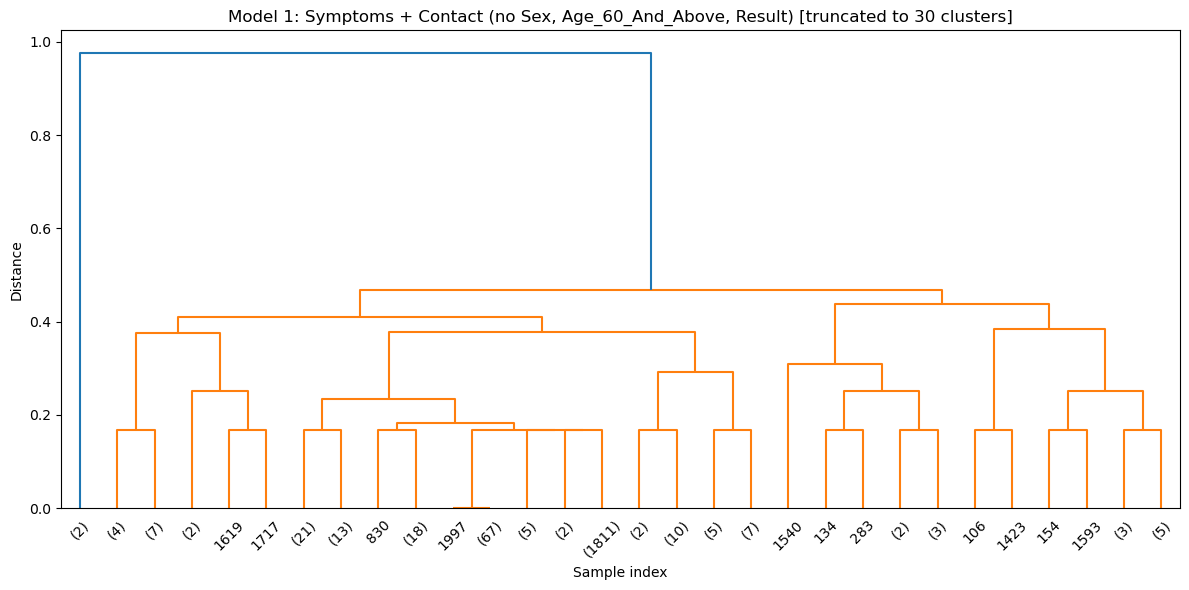

In [50]:
plt.figure(figsize=(12, 6))
dendrogram(HC1, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.title('Model 1: Symptoms + Contact (no Sex, Age_60_And_Above, Result) [truncated to 30 clusters]')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

Choose a distance cutoff (horizontal line) to get a desired number of clusters. Example: draw a line and count how many vertical lines it crosses.

### Cluster assignment (Model 1): 5 clusters

Cut the tree into 5 clusters and show how many people (and what %) fall in each cluster. Change `n_clusters` to 4 or another number if you prefer.

In [51]:
n_clusters = 5
labels1 = fcluster(HC1, t=n_clusters, criterion='maxclust')
df_sampled['cluster_m1'] = labels1
tab1 = df_sampled['cluster_m1'].value_counts().sort_index()
pct1 = (tab1 / len(df_sampled) * 100).round(1)
summary1 = pd.DataFrame({'Cluster': tab1.index, 'Count': tab1.values, 'Percent': pct1.values})
print('Model 1 (symptoms + contact only) — 5 clusters:')
print(summary1.to_string(index=False))
print(f'\nTotal: {len(df_sampled)}')

Model 1 (symptoms + contact only) — 5 clusters:
 Cluster  Count  Percent
       1      2      0.1
       2     15      0.8
       3   1963     98.2
       4      8      0.4
       5     12      0.6

Total: 2000


## Model 2: Features = symptoms + contact + Result (exclude only Sex, Age_60_And_Above)

In [52]:
features_model2 = ['Cough', 'Fever', 'Sore_Throat', 'Shortness_Of_Breath', 'Headache', 'Contact', 'Result']
X2 = df_sampled[features_model2]
# No scaling: binary 0/1; we use Hamming distance.
X2.shape

(2000, 7)

In [53]:
HC2 = linkage(X2, metric='hamming', method='average')

### Cluster assignment (Model 2): 5 clusters

Same cut (5 clusters) for Model 2. We also show **% COVID+ (Result=1)** in each cluster so you can see whether clusters line up with positive vs negative.

In [54]:
labels2 = fcluster(HC2, t=n_clusters, criterion='maxclust')
df_sampled['cluster_m2'] = labels2
tab2 = df_sampled['cluster_m2'].value_counts().sort_index()
pct2 = (tab2 / len(df_sampled) * 100).round(1)
pct_positive = df_sampled.groupby('cluster_m2')['Result'].mean().reindex(tab2.index) * 100
summary2 = pd.DataFrame({
    'Cluster': tab2.index,
    'Count': tab2.values,
    'Percent': pct2.values,
    '% COVID+': pct_positive.values.round(1)
})
print('Model 2 (symptoms + contact + Result) — 5 clusters:')
print(summary2.to_string(index=False))
print(f'\nTotal: {len(df_sampled)}  |  Overall % COVID+: {df_sampled["Result"].mean()*100:.1f}%')

Model 2 (symptoms + contact + Result) — 5 clusters:
 Cluster  Count  Percent  % COVID+
       1      2      0.1     100.0
       2      3      0.2     100.0
       3     63      3.2      93.7
       4      3      0.2      66.7
       5   1929     96.4       7.5

Total: 2000  |  Overall % COVID+: 10.5%


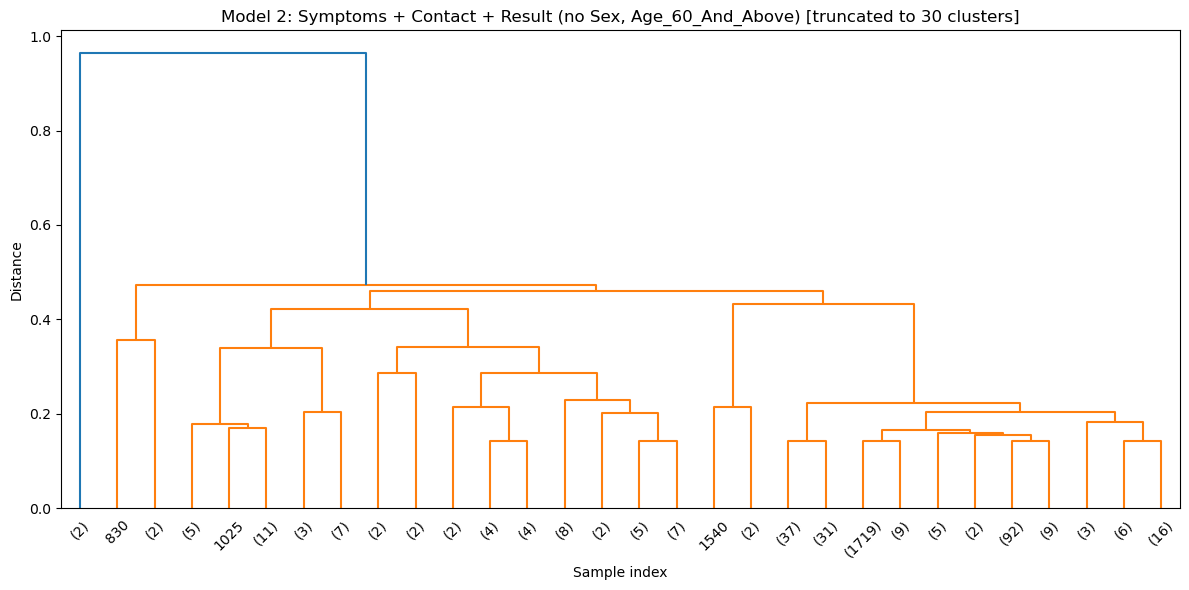

In [55]:
plt.figure(figsize=(12, 6))
dendrogram(HC2, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.title('Model 2: Symptoms + Contact + Result (no Sex, Age_60_And_Above) [truncated to 30 clusters]')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

Here clustering includes the COVID result (positive/negative), so clusters may separate more by outcome. Compare with Model 1 to see how much the target drives structure.

## Pulling insights from the clusters

**Recommendations:**

1. **Try different cluster numbers (k)** — Run the assignment with k = 3, 4, 5, or 6 and compare. Too few clusters can hide structure; too many can be noisy. The dendrogram suggests where big “jumps” in distance occur (good cut points).

2. **Look at variable percentages per cluster** — For each cluster, compute the **% of people with each feature = 1** (e.g. % with Cough, % with Contact). That “profile” tells you what each cluster represents (e.g. “mostly no symptoms, no contact” vs “high contact + fever”).

3. **Optionally exclude more variables** — If clusters are hard to interpret, try clustering on fewer features (e.g. only Contact + Fever + Cough) to see if clearer symptom/contact groups emerge. You can add a new model with a reduced feature set below.

In [56]:
# Compare cluster sizes for k = 3, 4, 5, 6 (helps choose a cluster count)
for k in [3, 4, 5, 6]:
    l1 = fcluster(HC1, t=k, criterion='maxclust')
    l2 = fcluster(HC2, t=k, criterion='maxclust')
    c1 = pd.Series(l1).value_counts().sort_index()
    c2 = pd.Series(l2).value_counts().sort_index()
    pct1 = (c1 / len(df_sampled) * 100).round(1)
    pct2 = (c2 / len(df_sampled) * 100).round(1)
    print(f'--- k = {k} ---')
    print('Model 1:', dict(zip(c1.index, [f'{c1.loc[i]} ({pct1.loc[i]}%)' for i in c1.index])))
    print('Model 2:', dict(zip(c2.index, [f'{c2.loc[i]} ({pct2.loc[i]}%)' for i in c2.index])))
    print()

--- k = 3 ---
Model 1: {1: '2 (0.1%)', 2: '1978 (98.9%)', 3: '20 (1.0%)'}
Model 2: {1: '2 (0.1%)', 2: '3 (0.2%)', 3: '1995 (99.8%)'}

--- k = 4 ---
Model 1: {1: '2 (0.1%)', 2: '1978 (98.9%)', 3: '8 (0.4%)', 4: '12 (0.6%)'}
Model 2: {1: '2 (0.1%)', 2: '3 (0.2%)', 3: '63 (3.2%)', 4: '1932 (96.6%)'}

--- k = 5 ---
Model 1: {1: '2 (0.1%)', 2: '15 (0.8%)', 3: '1963 (98.2%)', 4: '8 (0.4%)', 5: '12 (0.6%)'}
Model 2: {1: '2 (0.1%)', 2: '3 (0.2%)', 3: '63 (3.2%)', 4: '3 (0.2%)', 5: '1929 (96.4%)'}

--- k = 6 ---
Model 1: {1: '2 (0.1%)', 2: '15 (0.8%)', 3: '1963 (98.2%)', 4: '8 (0.4%)', 5: '2 (0.1%)', 6: '10 (0.5%)'}
Model 2: {1: '2 (0.1%)', 2: '3 (0.2%)', 3: '27 (1.4%)', 4: '36 (1.8%)', 5: '3 (0.2%)', 6: '1929 (96.4%)'}



### Variable profile per cluster (Model 1)

For each cluster, the table shows **% of people in that cluster with the feature = 1**. So you can name clusters (e.g. “low symptoms, no contact” vs “contact + fever”).

In [57]:
# Model 1: % of each feature = 1 by cluster (symptoms + contact only)
profile_m1 = df_sampled.groupby('cluster_m1')[features_model1].mean() * 100
profile_m1.round(1)

,Cough,Fever,Sore_Throat,Shortness_Of_Breath,Headache,Contact
cluster_m1,,,,,,
1,100.0,100.0,100.0,100.0,100.0,100.0
2,100.0,80.0,26.7,0.0,0.0,40.0
3,1.7,1.8,0.2,0.1,0.9,5.3
4,25.0,12.5,100.0,0.0,100.0,50.0
5,91.7,16.7,0.0,16.7,100.0,50.0


### Variable profile per cluster (Model 2)

Same idea for Model 2. The **Result** column is “% COVID+ in that cluster”; compare with overall ~10.5% to see which clusters are more positive or negative.

In [58]:
# Model 2: % of each feature = 1 by cluster (includes Result = % COVID+)
profile_m2 = df_sampled.groupby('cluster_m2')[features_model2].mean() * 100
profile_m2.round(1)

,Cough,Fever,Sore_Throat,Shortness_Of_Breath,Headache,Contact,Result
cluster_m2,,,,,,,
1,100.0,100.0,100.0,100.0,100.0,100.0,100.0
2,33.3,33.3,0.0,100.0,66.7,0.0,100.0
3,57.1,44.4,17.5,0.0,42.9,74.6,93.7
4,0.0,33.3,100.0,0.0,100.0,0.0,66.7
5,1.3,1.1,0.1,0.0,0.3,3.8,7.5


## Interpretation of the clustering results

### Summary

- **Sample:** 2,000 rows (stratified), ~10.5% COVID+ overall.
- **Model 1** clusters on **symptoms + contact only** (no Result).  
- **Model 2** clusters on **symptoms + contact + Result**, so clusters can separate by positive vs negative.

---

### Model 1 (symptoms + contact only) — what the clusters mean

With **k = 5**, one cluster dominates and a few small ones capture rare symptom patterns:

| Cluster | Size | Interpretation |
|--------|------|-----------------|
| **1** | 2 (0.1%) | **All symptoms + contact** — every feature = 1 (Cough, Fever, Sore throat, Shortness of breath, Headache, Contact). Very rare “full presentation” group. |
| **2** | 15 (0.8%) | **Cough + fever, some sore throat/contact** — 100% cough, 80% fever, 27% sore throat, 40% contact; no shortness of breath or headache. “Respiratory + fever” without severe symptoms. |
| **3** | 1,963 (98.2%) | **Low symptoms, low contact** — &lt;2% on every feature. This is the **bulk of the sample**: people with few or no symptoms and little reported contact. |
| **4** | 8 (0.4%) | **Sore throat + headache, some cough/contact** — 100% sore throat and headache, 25% cough, 50% contact. “Throat + headache” profile. |
| **5** | 12 (0.6%) | **Cough + headache, some fever/shortness** — 92% cough, 100% headache, 17% fever, 17% shortness, 50% contact. “Cough + headache” with occasional respiratory. |

**Takeaway:** Most people fall into a single “low-everything” cluster (3). The other clusters are small groups with distinct symptom combinations (e.g. cough+fever, sore throat+headache). So **symptom/contact patterns alone** don’t split the sample into many balanced groups; they mainly separate a few rare “symptom-heavy” profiles from the majority.

---

### Model 2 (symptoms + contact + Result) — COVID+ drives the split

Including **Result** changes the story: clusters align much more with **positive vs negative**:

| Cluster | Size | % COVID+ | Interpretation |
|--------|------|----------|----------------|
| **1** | 2 (0.1%) | 100% | Tiny; all COVID+. |
| **2** | 3 (0.2%) | 100% | Tiny; all COVID+. |
| **3** | 63 (3.2%) | **93.7%** | **COVID+ cluster** — most of these are positive; likely more symptoms/contact. |
| **4** | 3 (0.2%) | 66.7% | Very small; mixed. |
| **5** | 1,929 (96.4%) | **7.5%** | **Mainly COVID−** — size and low % COVID+ match the overall negative majority. |

**Takeaway:** Once Result is in the feature set, the algorithm largely separates **positive cases** (clusters 1–4, high % COVID+) from **negative cases** (cluster 5, ~7.5% COVID+). So **knowing the test result would largely determine cluster membership**; the structure is strongly driven by the outcome, not only by symptom/contact patterns.

---

### Comparing the two models

- **Model 1:** Structure is mostly “one big low-symptom/low-contact group” plus a few small clusters with specific symptom combos. Useful for **profiling symptom patterns** without using the outcome.
- **Model 2:** Structure is mostly “COVID+ vs COVID−.” Useful to see that **symptoms + contact + result** cluster mainly by positivity; it does **not** show that symptoms/contact alone create clear, balanced COVID+ vs COVID− groups (that would require Model 1 to split that way, which it doesn’t).

---

### Choosing k and next steps

- **k = 3 or 4** gives a single huge cluster and 1–2 small ones; **k = 5 or 6** adds a bit more detail but still one dominant cluster. So the **data are skewed**: one main “low-everything” group and several tiny “symptom-specific” groups.
- **Variable profiles** (the tables above) are the right way to **name and interpret** each cluster (e.g. “cough + fever, no shortness”).
- To see if **fewer variables** (e.g. Contact + Fever + Cough only) give clearer or more balanced clusters, you can run the same pipeline on a reduced feature set and compare sizes and profiles.